In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, roc_curve, classification_report)
from sklearn.calibration import calibration_curve


In [17]:
PROJECT_ROOT = Path('../')
DATA_OUT     = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

In [18]:
X_train = pd.read_csv(DATA_OUT / 'X_train.csv')
X_test  = pd.read_csv(DATA_OUT / 'X_test.csv')
y_train = pd.read_csv(DATA_OUT / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_OUT / 'y_test.csv').squeeze()

race_map = {1: 'Mexican American', 2: 'Other Hispanic', 3: 'NH White',
            4: 'NH Black', 6: 'NH Asian', 7: 'Other/Multi'}
sex_map  = {1: 'Male', 2: 'Female'}

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.mean():.1%} diabetic")
print(f"Test class balance:  {y_test.mean():.1%} diabetic")

Train: (13200, 5), Test: (3301, 5)
Train class balance: 15.1% diabetic
Test class balance:  15.1% diabetic


Train Logistic Regression on the Imbalanced Data


In [19]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=None  # explicitly no balancing — this is the imbalanced baseline
)

lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [20]:
y_pred       = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

print("Overall performance")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Overall performance
              precision    recall  f1-score   support

 No Diabetes       0.92      0.98      0.95      2803
    Diabetes       0.83      0.52      0.64       498

    accuracy                           0.91      3301
   macro avg       0.87      0.75      0.80      3301
weighted avg       0.91      0.91      0.90      3301

AUC: 0.8967


In [21]:
joblib.dump(lr, DATA_OUT / 'lr_baseline.pkl')
print("Saved lr_baseline.pkl")

Saved lr_baseline.pkl


Per-subgroup metrics function

In [22]:
def compute_subgroup_metrics(model, X, y, group_col, group_map, group_name):
    """
    Compute AUC, F1, precision, recall per subgroup.
    Returns a DataFrame of results.
    """
    results = []
    groups = X[group_col].map(group_map)

    for group_label in sorted(groups.unique()):
        mask = groups == group_label
        X_grp = X[mask]
        y_grp = y[mask]

        if y_grp.sum() < 5:  # skip groups with too few positive cases
            print(f"Skipping {group_label} — too few positive cases ({y_grp.sum()})")
            continue

        proba = model.predict_proba(X_grp)[:, 1]
        pred  = model.predict(X_grp)

        results.append({
            'group_type':  group_name,
            'group':       group_label,
            'n':           len(y_grp),
            'n_diabetic':  int(y_grp.sum()),
            'prevalence':  y_grp.mean(),
            'auc':         roc_auc_score(y_grp, proba),
            'f1':          f1_score(y_grp, pred, zero_division=0),
            'precision':   precision_score(y_grp, pred, zero_division=0),
            'recall':      recall_score(y_grp, pred, zero_division=0),
        })

    return pd.DataFrame(results)

In [23]:
race_metrics = compute_subgroup_metrics(
    lr, X_test, y_test,
    group_col='RIDRETH3', group_map=race_map, group_name='race'
)

sex_metrics = compute_subgroup_metrics(
    lr, X_test, y_test,
    group_col='RIAGENDR', group_map=sex_map, group_name='sex'
)

# Overall metrics row
overall_proba = lr.predict_proba(X_test)[:, 1]
overall_pred  = lr.predict(X_test)
overall_metrics = pd.DataFrame([{
    'group_type': 'overall',
    'group':      'All',
    'n':          len(y_test),
    'n_diabetic': int(y_test.sum()),
    'prevalence': y_test.mean(),
    'auc':        roc_auc_score(y_test, overall_proba),
    'f1':         f1_score(y_test, overall_pred, zero_division=0),
    'precision':  precision_score(y_test, overall_pred, zero_division=0),
    'recall':     recall_score(y_test, overall_pred, zero_division=0),
}])

# Combine all
all_metrics = pd.concat([overall_metrics, race_metrics, sex_metrics], ignore_index=True)
all_metrics['model'] = 'lr_baseline'
all_metrics = all_metrics.round(4)

print(all_metrics.to_string(index=False))

group_type            group    n  n_diabetic  prevalence    auc     f1  precision  recall       model
   overall              All 3301         498      0.1509 0.8967 0.6421     0.8286  0.5241 lr_baseline
      race Mexican American  311          54      0.1736 0.8754 0.5556     0.6944  0.4630 lr_baseline
      race         NH Asian  291          40      0.1375 0.8790 0.5714     0.6667  0.5000 lr_baseline
      race         NH Black  669         120      0.1794 0.8832 0.6211     0.8429  0.4917 lr_baseline
      race         NH White 1513         201      0.1328 0.9137 0.6792     0.9231  0.5373 lr_baseline
      race   Other Hispanic  332          51      0.1536 0.9120 0.6882     0.7619  0.6275 lr_baseline
      race      Other/Multi  185          32      0.1730 0.8916 0.6538     0.8500  0.5312 lr_baseline
       sex           Female 1776         253      0.1425 0.8955 0.5965     0.8151  0.4704 lr_baseline
       sex             Male 1525         245      0.1607 0.8988 0.6860     0.8402 

In [24]:
all_metrics.to_csv(DATA_OUT / 'metrics_lr_baseline.csv', index=False)
print("Saved metrics_lr_baseline.csv")

Saved metrics_lr_baseline.csv


In [25]:
master_metrics_path = DATA_OUT / 'all_model_metrics.csv'

if master_metrics_path.exists():
    master = pd.read_csv(master_metrics_path)
    master = pd.concat([master, all_metrics], ignore_index=True)
else:
    master = all_metrics.copy()

master.to_csv(master_metrics_path, index=False)
print("Updated all_model_metrics.csv")

Updated all_model_metrics.csv


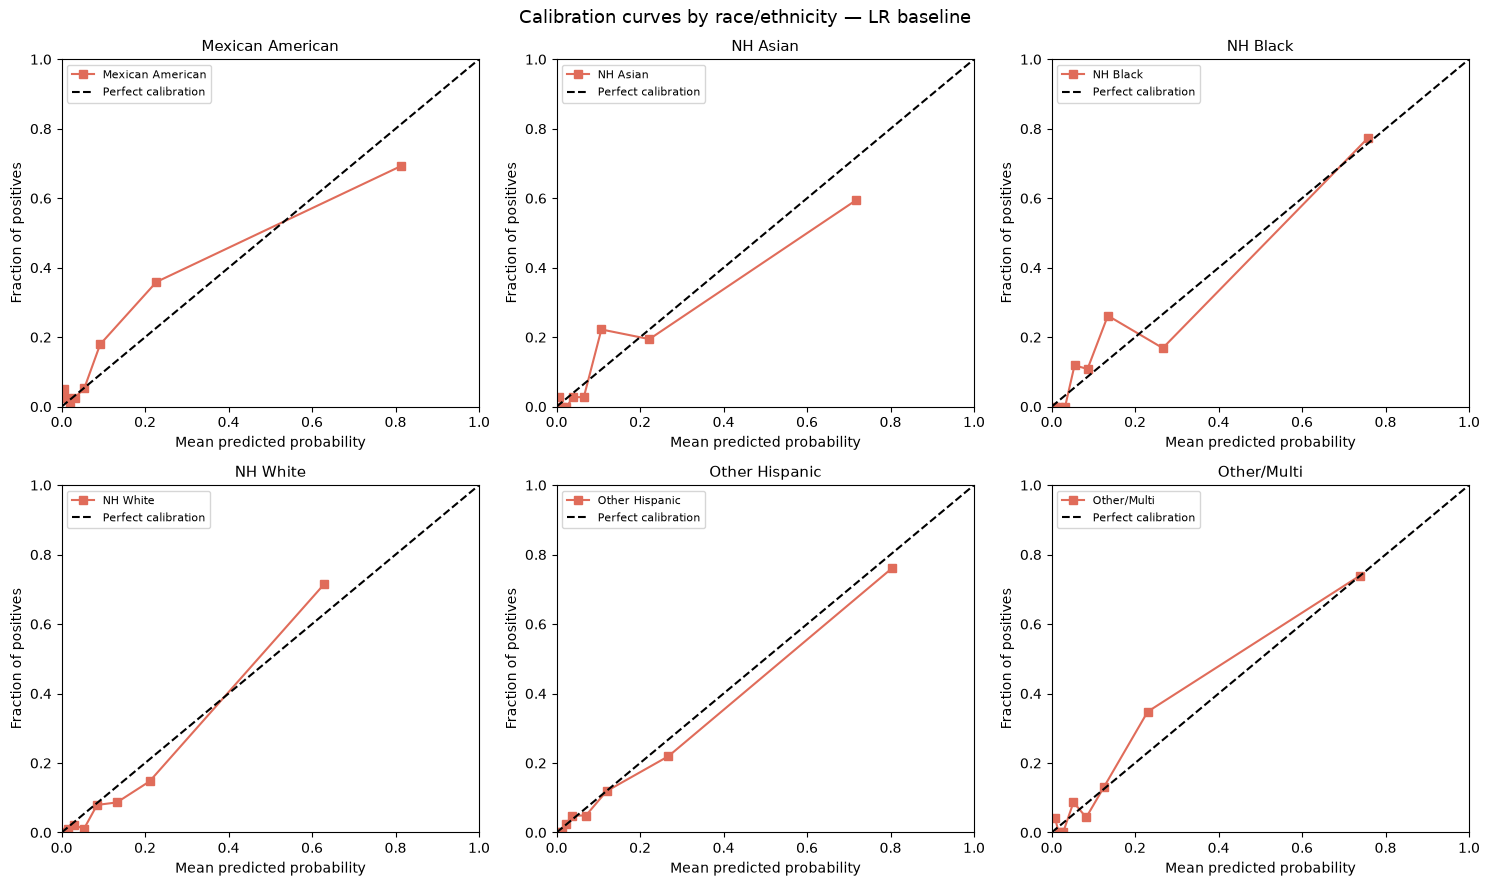

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

groups = X_test['RIDRETH3'].map(race_map)

for i, group_label in enumerate(sorted(groups.unique())):
    mask  = groups == group_label
    proba = lr.predict_proba(X_test[mask])[:, 1]
    y_grp = y_test[mask]

    fraction_pos, mean_pred = calibration_curve(y_grp, proba, n_bins=8, strategy='quantile')

    axes[i].plot(mean_pred, fraction_pos, 's-', label=group_label, color='#E06C5A')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[i].set_title(group_label, fontsize=11)
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

# Hide unused subplot if fewer than 6 groups
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Calibration curves by race/ethnicity — LR baseline', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_calibration_by_race_lr.png', dpi=150)
plt.show()

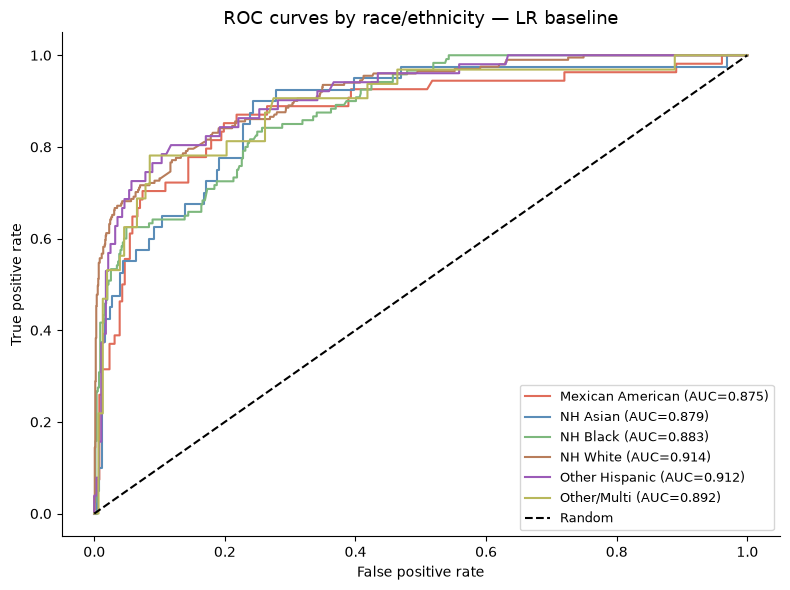

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E06C5A', '#5B8DB8', '#7DB87D', '#B87D5B', '#9B5BB8', '#B8B85B']

for color, group_label in zip(colors, sorted(groups.unique())):
    mask  = groups == group_label
    proba = lr.predict_proba(X_test[mask])[:, 1]
    y_grp = y_test[mask]

    fpr, tpr, _ = roc_curve(y_grp, proba)
    auc = roc_auc_score(y_grp, proba)
    ax.plot(fpr, tpr, label=f'{group_label} (AUC={auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves by race/ethnicity — LR baseline', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_roc_by_race_lr.png', dpi=150)
plt.show()

Background dataset has 13200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=13200 when initializing the masker.


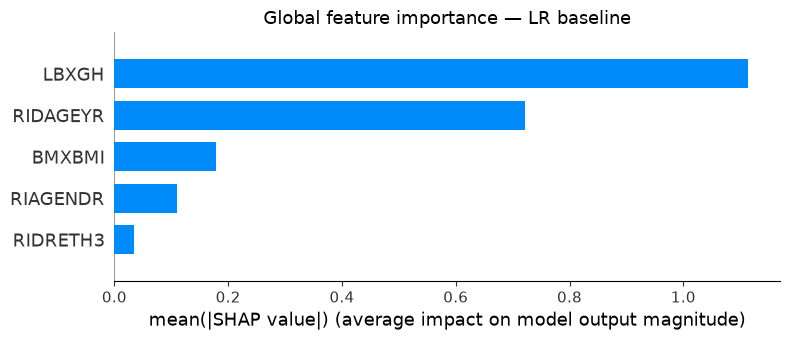

In [28]:
# shap.LinearExplainer is the right choice for logistic regression — fast and exact
explainer   = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test)

# Feature name mapping for readable plots
feature_names = X_test.columns.tolist()

# Global feature importance bar chart
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('Global feature importance — LR baseline', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_shap_global_lr.png', dpi=150, bbox_inches='tight')
plt.show()

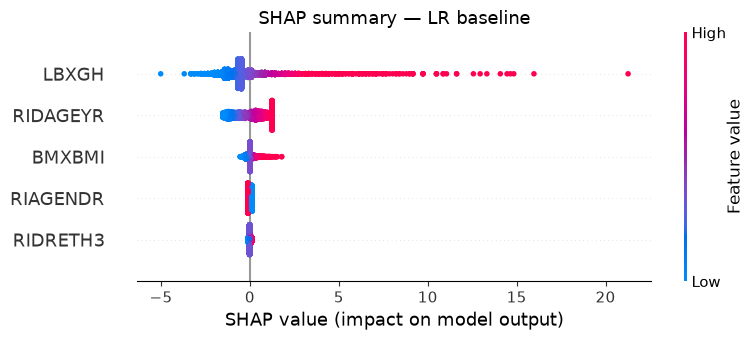

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP summary — LR baseline', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_shap_summary_lr.png', dpi=150, bbox_inches='tight')
plt.show()

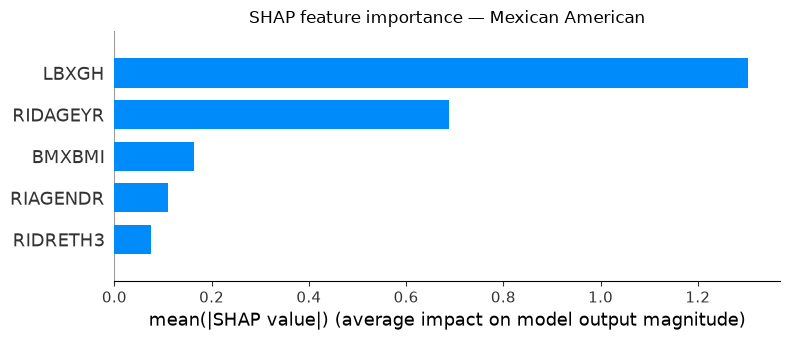

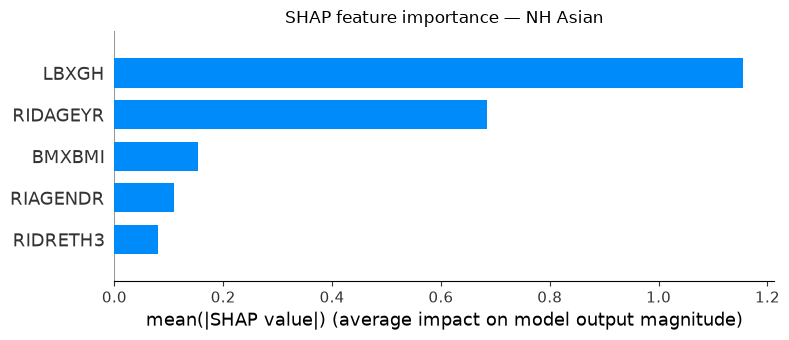

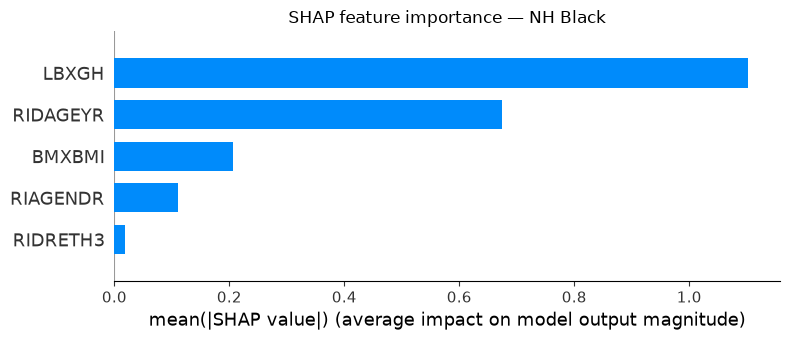

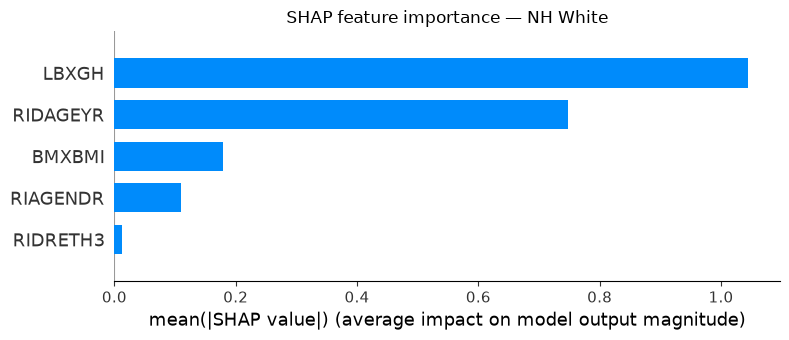

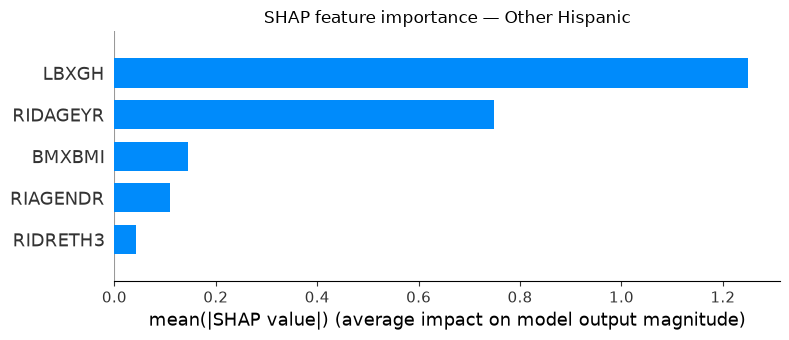

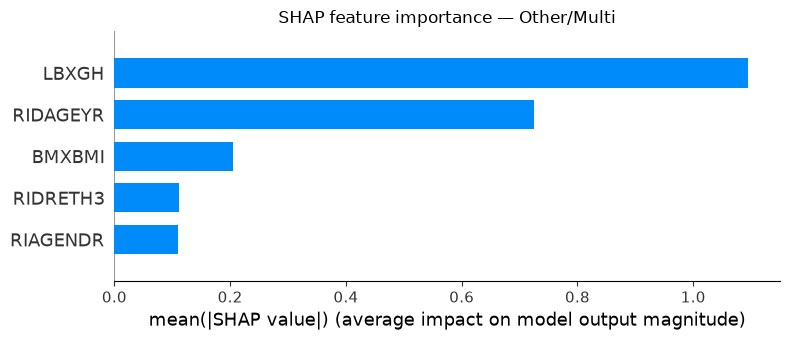

In [30]:
for group_label in sorted(groups.unique()):
    mask = (groups == group_label).values
    shap_grp = shap_values[mask]
    X_grp    = X_test[mask]

    fig, ax = plt.subplots(figsize=(8, 4))
    shap.summary_plot(shap_grp, X_grp, feature_names=feature_names,
                      plot_type='bar', show=False)
    plt.title(f'SHAP feature importance — {group_label}', fontsize=12)
    plt.tight_layout()

    fname = group_label.replace('/', '_').replace(' ', '_')
    plt.savefig(FIGURES_DIR / f'fig_shap_{fname}_lr.png', dpi=150, bbox_inches='tight')
    plt.show()